In [ ]:
import os
import csv
import cv2 as cv
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from google.colab import drive

print("PyTorch version: " + torch.__version__)

# Setup GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
Using device: cuda


In [ ]:
########################################################################################################################
# MOUNTING GOOGLE DRIVE
########################################################################################################################

drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/VAE_MNIST_Results_PyTorch'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Mounted at /content/drive
Napravljen direktorijum za rezultate na Drive-u: /content/drive/MyDrive/VAE_MNIST_Results_PyTorch


In [ ]:
########################################################################################################################
# PARAMETERS
########################################################################################################################

latent_dim = 2
batch_size = 512

init_lr = 1e-3
reduce_lr_patience = 10
reduce_lr_cooldown = 5
early_stopping_patience = 3 * (reduce_lr_patience + reduce_lr_cooldown)
max_epochs = 1000

vae_path = os.path.join(drive_results_folder, f'trained_vae_{latent_dim}d.pth')
training_log_path = os.path.join(drive_results_folder, f'training_log_{latent_dim}d.csv')
training_loss_path = os.path.join(drive_results_folder, f'training_loss_{latent_dim}d.png')
features_path = os.path.join(drive_results_folder, f'features_{latent_dim}d.csv')
features_scatter_path = os.path.join(drive_results_folder, f'features_{latent_dim}d_scatter.png')
visualization_path = os.path.join(drive_results_folder, f'visualization_{latent_dim}d.png')

In [ ]:
########################################################################################################################
# LOADING AND PROCESSING DATASET
########################################################################################################################

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()]) # Natively scales to [0, 1]
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Concatenate train and validation sets
x_train = torch.cat((train_set.data, test_set.data), dim=0).float() / 255.0
y_train = torch.cat((train_set.targets, test_set.targets), dim=0)

# Display some statistics
unique, counts = torch.unique(y_train, return_counts=True)
print(dict(zip(unique.tolist(), counts.tolist())))

# Add channel dimension (PyTorch uses N, C, H, W)
x_train = x_train.unsqueeze(1)
print(f"Dataset shape: {x_train.shape}")
image_size = x_train.shape[2:]

# Create DataLoader
dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.88MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


{0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}
Dataset shape: torch.Size([70000, 1, 28, 28])


In [ ]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        y1 = F.relu(self.bn1(self.conv1(x)))
        y2 = self.bn2(self.conv2(y1))
        # Residual connection matches your Keras: Add(y1, y2)
        return F.relu(y1 + y2)

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.block1 = ResBlock(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.block2 = ResBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.block3 = ResBlock(64, 128)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_mean = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

    def forward(self, x):
        y = self.block1(x)
        y = self.pool1(y)
        y = self.block2(y)
        y = self.pool2(y)
        y = self.block3(y)
        y = self.global_pool(y)
        y = torch.flatten(y, 1)

        z_mean = self.fc_mean(y)
        z_log_var = self.fc_logvar(y)
        return z_mean, z_log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 7 * 7 * 128)
        self.block1 = ResBlock(128, 128)
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.block2 = ResBlock(128, 64)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.block3 = ResBlock(64, 32)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, z):
        y = F.relu(self.fc(z))
        y = y.view(-1, 128, 7, 7)

        y = self.block1(y)
        y = self.up1(y)
        y = self.block2(y)
        y = self.up2(y)
        y = self.block3(y)

        # Sigmoid to constrain outputs between 0 and 1
        y = torch.sigmoid(self.final_conv(y))
        return y

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, z_mean, z_log_var):
        std = torch.exp(0.5 * z_log_var)
        eps = torch.randn_like(std)
        return z_mean + eps * std

    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        recon_x = self.decoder(z)
        return recon_x, z_mean, z_log_var, z

def vae_loss_fn(recon_x, x, z_mean, z_log_var):
    # Reconstruction loss (Sum of squared errors per image)
    recon_loss = F.mse_loss(recon_x, x, reduction='none')
    recon_loss = torch.sum(recon_loss, dim=[1, 2, 3])

    # KL Divergence
    kl_loss = 1 + z_log_var - torch.square(z_mean) - torch.exp(z_log_var)
    kl_loss = torch.sum(kl_loss, dim=1)

    # Total loss (Mean over the batch)
    return torch.mean(recon_loss - 0.5 * kl_loss)

VAE(
  (encoder): Encoder(
    (block1): ResBlock(
      (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block2): ResBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block3): ResBlock(
      (conv1): Con

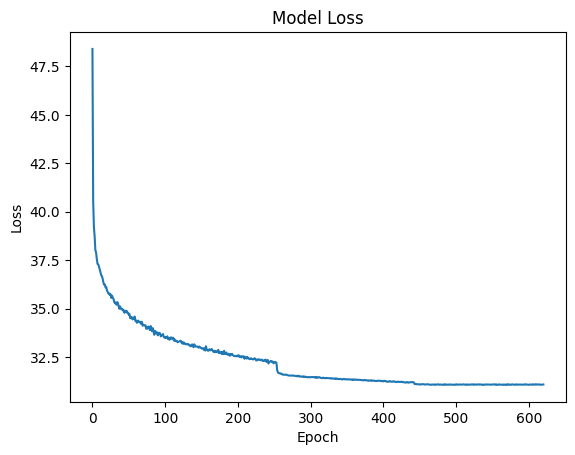

In [ ]:
########################################################################################################################
# TRAIN MODEL
########################################################################################################################

model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=init_lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1,
                                                 patience=reduce_lr_patience,
                                                 cooldown=reduce_lr_cooldown)

print(model)

# Training Loop setup
best_loss = float('inf')
epochs_no_improve = 0
history_loss = []

# Prepare CSV Log
with open(training_log_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss', 'lr'])

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0.0

    for batch_idx, (data, _) in enumerate(dataloader):
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, z_mean, z_log_var, _ = model(data)
        loss = vae_loss_fn(recon_batch, data, z_mean, z_log_var)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_loss = train_loss / len(dataloader)
    history_loss.append(avg_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}/{max_epochs} - loss: {avg_loss:.4f} - lr: {current_lr}")

    # Log to CSV
    with open(training_log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, avg_loss, current_lr])

    # LR Scheduler
    scheduler.step(avg_loss)

    # Model Checkpointing & Early Stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), vae_path)
        print(f"Saved better model (loss: {best_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

# Plot Training Loss
plt.clf()
plt.plot(history_loss)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.savefig(training_loss_path)
plt.show()


Extracting features
.........................................................................................................................................


<Figure size 640x480 with 0 Axes>

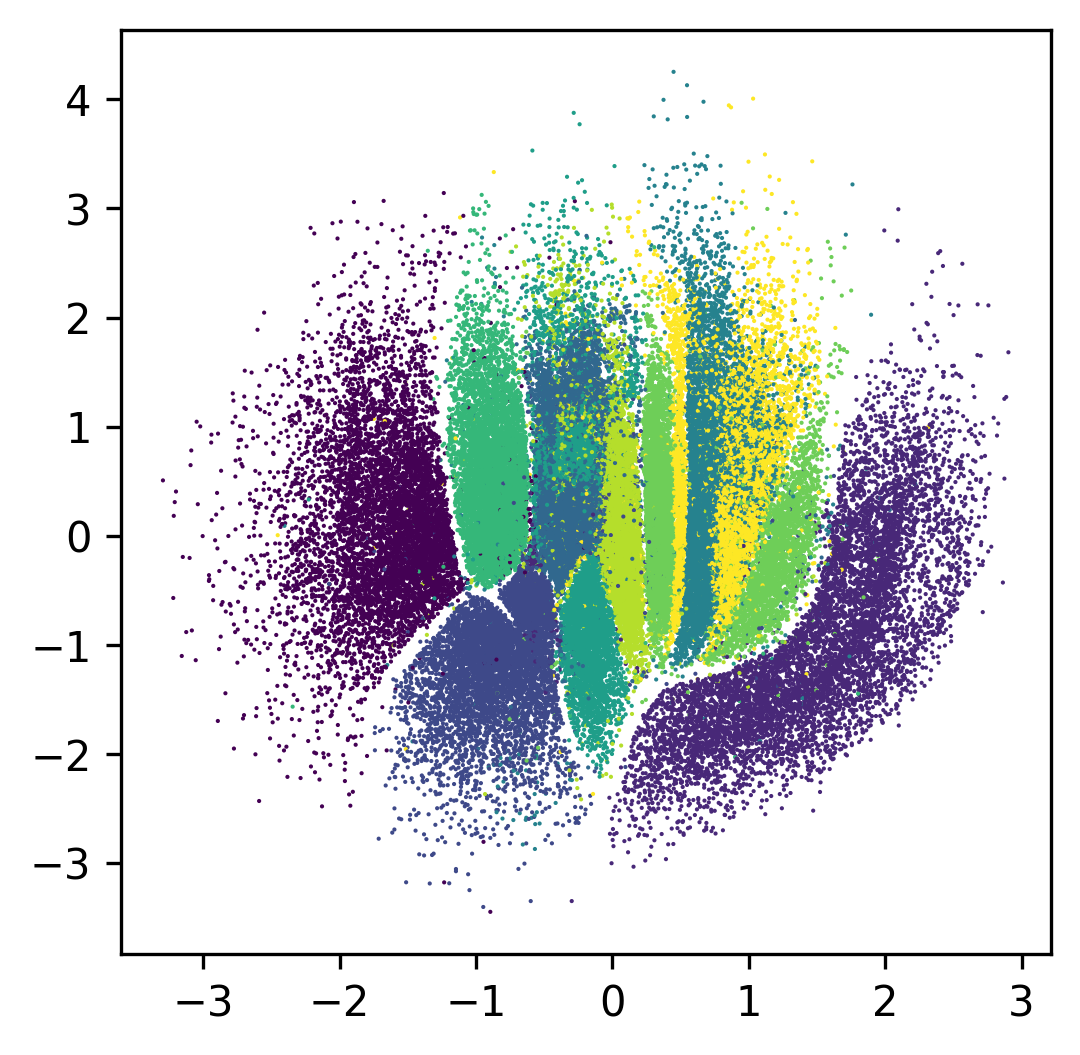

zx_min = -3.30, zx_max = 2.90
zy_min = -3.45, zy_max = 4.25
Generating images
........................................


<Figure size 640x480 with 0 Axes>

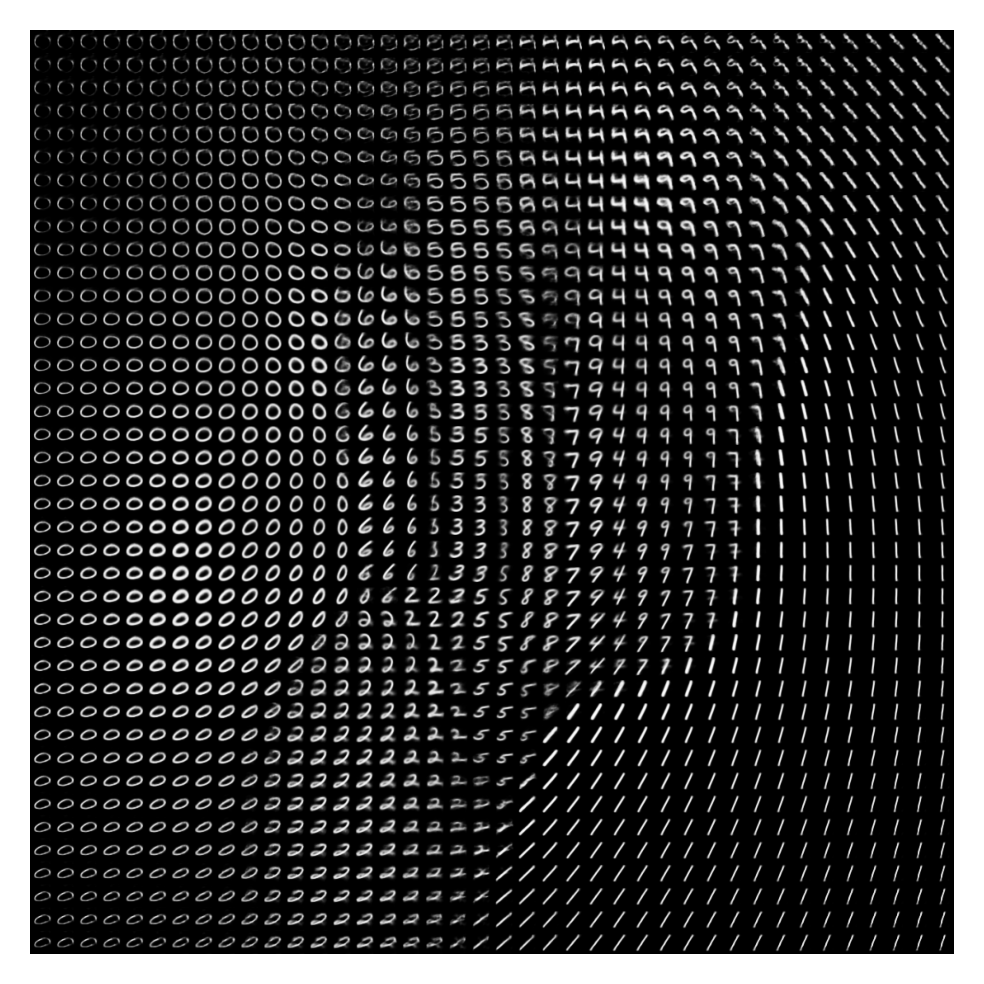

In [ ]:
########################################################################################################################
# EVALUATE
########################################################################################################################

# LOAD BEST MODEL
model.load_state_dict(torch.load(vae_path))
model.eval()

# EXTRACT FEATURES USING VAE ENCODER
print('\nExtracting features')
header = ['digit'] + [f'f{i+1}' for i in range(latent_dim)]
flist = [header]

# Create sequential dataloader for feature extraction without shuffling
eval_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

z_train = []
y_train_list = []

with torch.no_grad():
    for data, targets in eval_loader:
        data = data.to(device)
        z_mean, _ = model.encoder(data)
        z_train.append(z_mean.cpu().numpy())
        y_train_list.append(targets.numpy())
        print('.', end='')
print()

z_train = np.concatenate(z_train, axis=0)
y_train_arr = np.concatenate(y_train_list, axis=0)

# Populate feature list
for i in range(len(z_train)):
    f = [y_train_arr[i]] + z_train[i].tolist()
    flist.append(f)

# Save features to CSV
with open(features_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(flist)

# Visualize 2D feature using scatter plot
if latent_dim == 2:
    features_df = pd.read_csv(features_path)
    plt.clf()
    plt.figure(figsize=(4, 4), dpi=300)
    plt.scatter(features_df['f1'], features_df['f2'], c=features_df['digit'], cmap='viridis', s=1, linewidths=0)
    plt.savefig(features_scatter_path)
    plt.show()

# GENERATE GRID OF IMAGES WITH VAE DECODER BY SAMPLING Z
if latent_dim == 2:
    n = 40 # Number of steps

    # Range of latent variables
    zx_min, zx_max = np.min(z_train[:, 0]), np.max(z_train[:, 0])
    zy_min, zy_max = np.min(z_train[:, 1]), np.max(z_train[:, 1])
    print(f'zx_min = {zx_min:.2f}, zx_max = {zx_max:.2f}')
    print(f'zy_min = {zy_min:.2f}, zy_max = {zy_max:.2f}')

    print('Generating images')
    # Use spatial dimensions dynamically (28x28)
    img_h, img_w = image_size[0], image_size[1]
    img = np.zeros((n * img_h, n * img_w), dtype=np.uint8)

    with torch.no_grad():
        for i in range(n):
            for j in range(n):
                # Generate latent vector z
                x_val = zx_min + j * (zx_max - zx_min) / (n - 1)
                y_val = zy_min + (n - 1 - i) * (zy_max - zy_min) / (n - 1)
                z = torch.tensor([[x_val, y_val]], dtype=torch.float32).to(device)

                # Decode z back to an image
                y_out = model.decoder(z)

                # Re-scale back to [0, 255] and move channel to end
                y_out = y_out.cpu().numpy()[0, 0, :, :] * 255.0
                img_patch = np.clip(np.round(y_out), 0, 255).astype(np.uint8)

                # Place in grid
                img[i*img_h:(i+1)*img_h, j*img_w:(j+1)*img_w] = img_patch
            print('.', end='')
    print()

    # Save image grid
    cv.imwrite(visualization_path, img)
    plt.clf()
    plt.figure(figsize=(4, 4), dpi=300)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()